In [55]:
import pandas as pd
import datetime as dt
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import OneClassSVM
from imblearn.over_sampling import SMOTE
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import metrics
import lime
import lime.lime_tabular

In [56]:
df = pd.read_csv("ResearhData.csv")
print(df.shape)
df.head()

(2541, 13)


,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
0,NOSTRESS,-0.030326,-0.030742,0.000124,0.0,0.0,-0.810,0.3750,-1.121333,-0.036966,-0.5,-33.871843,-0.488629
1,NOSTRESS,-0.027412,-0.028501,0.003034,0.0,0.0,-1.320,0.3675,-0.771936,0.317007,-0.5,-33.871843,-0.488629
2,NOSTRESS,-0.027540,-0.028821,0.002604,0.0,0.0,-1.380,0.3625,-0.913694,0.263580,-0.5,-33.871843,-0.488629
3,NOSTRESS,-0.018734,-0.016492,0.004473,0.0,0.0,-2.285,0.4050,-0.272774,0.462842,-0.5,-33.871843,-0.488629
4,NOSTRESS,-0.012041,-0.014570,-0.005277,0.0,0.0,-2.715,0.4125,0.057561,0.002796,-0.5,-33.871843,-0.488629


In [57]:
df['Label'].unique()

array(['NOSTRESS', 'STRESS'], dtype=object)

## Data Description 

In [58]:
df.describe(include='all')

,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
count,2541,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,STRESS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.133460,0.134660,0.011387,0.226682,0.025125,9.303126,-0.317973,-0.110210,0.621465,-1.519776,-31.099023,-0.441252
std,NaN,0.310719,0.314339,0.039412,0.783278,0.105890,14.661003,0.599100,0.877497,1.110321,13.332870,32.091973,4.118833
min,NaN,-1.083348,-1.065445,-0.064407,-4.000000,-0.219829,-29.775000,-2.073750,-11.392412,-7.634984,-43.500000,-99.875000,-18.977173
25%,NaN,0.038008,0.039704,-0.000006,0.000000,0.000000,0.325000,-0.748750,-0.581779,0.045387,-10.000000,-52.300000,-2.154263
50%,NaN,0.085989,0.086309,0.001395,0.000000,0.000000,7.800000,-0.265000,-0.127017,0.250669,-0.500000,-33.871843,-0.488629
75%,NaN,0.157703,0.159619,0.007714,0.000000,0.000000,15.570000,0.067500,0.366051,0.993110,8.000000,-11.863636,1.978926


## Missingness

In [59]:
missing_counts = df.isnull().sum()

missing_counts = missing_counts[missing_counts > 2541/2]

missing_counts.sort_values(ascending=False)

Series([], dtype: int64)

## Low Variability

In [60]:
from sklearn.feature_selection import VarianceThreshold

df_num = df.select_dtypes(include=['number'])

# Set your variance threshold (e.g., 0.01 is a common starting point)
my_threshold = 0.01
selector = VarianceThreshold(threshold=my_threshold)
selector.fit(df_num)

# Get boolean mask of features that pass the threshold
mask = selector.get_support()

# Get list of all column names
all_features = df_num.columns

# Features that were removed (low variance)
low_variability_features = all_features[~mask]

# Show the names of low-variability columns
print("Low variability features (variance < {:.2f}):".format(my_threshold))
print(low_variability_features.tolist())

Low variability features (variance < 0.01):
['EDA_sd_delta']


In [61]:
for col in df.select_dtypes(include='object'):
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        print(f"{col} ({top_freq:.1%})")

In [62]:
df.dtypes

Label                 object
EDA_mean_delta       float64
EDA_median_delta     float64
EDA_sd_delta         float64
SCR_count_delta      float64
SCR_amp_delta        float64
HR_median_delta      float64
TEMP_median_delta    float64
ACC_vm_mean_delta    float64
ACC_vm_sd_delta      float64
HR_bangle_delta      float64
HR_conf_delta        float64
RMSSD_ECG_delta      float64
dtype: object

## Sampling 

In [63]:
pd.crosstab(index = df['Label'], columns = "count") 

col_0,count
Label,
NOSTRESS,1229
STRESS,1312


In [64]:
train = df.groupby("Label", group_keys=False).sample(frac=0.75, random_state=1234)
test = df.loc[df.index.difference(train.index)]
train.head()


,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
2220,NOSTRESS,-0.091091,-0.091315,0.000187,-2.0,-0.043149,35.41,-0.2400,-0.450977,0.439211,-1.0,-62.000000,-4.964245
850,NOSTRESS,-0.031503,-0.033947,0.009839,0.5,0.041946,57.27,-1.3125,-0.497868,2.271804,10.0,-54.428571,-1.730073
427,NOSTRESS,0.194776,0.194680,-0.000229,0.0,0.000000,-28.80,1.3750,1.841169,0.090760,2.0,-44.550000,-0.622952
1162,NOSTRESS,0.340880,0.340912,0.000109,0.5,0.041793,11.06,-0.5550,-0.509152,0.090518,-19.0,-32.500000,-1.842775
849,NOSTRESS,-0.043683,-0.041794,0.002562,0.0,0.000000,56.23,-1.3225,0.495889,0.220549,8.5,-57.918182,-4.616893


In [65]:
pd.crosstab(index = train['Label'], columns = "count")


col_0,count
Label,
NOSTRESS,922
STRESS,984


In [66]:
pd.crosstab(index = test['Label'], columns = "count")


col_0,count
Label,
NOSTRESS,307
STRESS,328


In [67]:
# filling in number dtypes with median and flagging with missing 
train_o = train.copy()
num_cols = train_o.select_dtypes(include='number').columns

for col in num_cols:
    if train_o[col].isnull().any():
        # Create missing flag column
        train_o[f'{col}_was_missing'] = train_o[col].isnull().astype(int)

        # Impute with median
        median = train_o[col].median()
        train_o[col] = train_o[col].fillna(median)
print(train_o.columns)

Index(['Label', 'EDA_mean_delta', 'EDA_median_delta', 'EDA_sd_delta',
       'SCR_count_delta', 'SCR_amp_delta', 'HR_median_delta',
       'TEMP_median_delta', 'ACC_vm_mean_delta', 'ACC_vm_sd_delta',
       'HR_bangle_delta', 'HR_conf_delta', 'RMSSD_ECG_delta'],
      dtype='object')


In [68]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(train_o.dtypes)


Label                 object
EDA_mean_delta       float64
EDA_median_delta     float64
EDA_sd_delta         float64
SCR_count_delta      float64
SCR_amp_delta        float64
HR_median_delta      float64
TEMP_median_delta    float64
ACC_vm_mean_delta    float64
ACC_vm_sd_delta      float64
HR_bangle_delta      float64
HR_conf_delta        float64
RMSSD_ECG_delta      float64
dtype: object


In [69]:
# creating X and Y and creating dummies for categorical data 
predictors = train_o.drop(columns=['Label'])
predictors = pd.get_dummies(predictors, drop_first=True)
predictors = predictors.astype(float)

X = predictors

y = train_o['Label']



In [70]:
# using Pearson's square to sort data and determine association, 
# Use p-value of 0.002 depending on the data siize
from sklearn.feature_selection import SelectKBest, chi2, f_classif

# Separate categorical (dummy) vs. continuous features
continuous_features = [col for col in X.columns if X[col].nunique() > 2]

X_cont = X[continuous_features]




# Fit SelectKBest for Continous Variables
selector = SelectKBest(score_func=f_classif, k='all')  # 'all' keeps all features for scoring
selector.fit(X_cont, y)

# Create a DataFrame with feature names, F-scores, and p-values
scores_cont_df = pd.DataFrame({
    'Feature': X_cont.columns,
    'F_score': selector.scores_,
    'p_value': selector.pvalues_
})

# Filter for features with p-value < 0.002
selected_cont_features = scores_cont_df[scores_cont_df['p_value'] < 0.002]['Feature']

# Create a new DataFrame with only those selected columns
X_reduced = X[selected_cont_features.tolist()]

X_reduced.head()


,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,TEMP_median_delta,ACC_vm_sd_delta,HR_bangle_delta
2220,-0.091091,-0.091315,0.000187,-2.0,-0.043149,-0.2400,0.439211,-1.0
850,-0.031503,-0.033947,0.009839,0.5,0.041946,-1.3125,2.271804,10.0
427,0.194776,0.194680,-0.000229,0.0,0.000000,1.3750,0.090760,2.0
1162,0.340880,0.340912,0.000109,0.5,0.041793,-0.5550,0.090518,-19.0
849,-0.043683,-0.041794,0.002562,0.0,0.000000,-1.3225,0.220549,8.5


In [71]:
#first model
import statsmodels.api as sm
y = train_o['Label'].map({'NOSTRESS': 0, 'STRESS': 1})

X_reduced = sm.add_constant(X_reduced)

# Build Logistic Regression
model = sm.Logit(y, X_reduced)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.632184
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Label   No. Observations:                 1906
Model:                          Logit   Df Residuals:                     1897
Method:                           MLE   Df Model:                            8
Date:                Mon, 26 Jan 2026   Pseudo R-squ.:                 0.08725
Time:                        10:47:54   Log-Likelihood:                -1204.9
converged:                       True   LL-Null:                       -1320.1
Covariance Type:            nonrobust   LLR p-value:                 2.468e-45
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0823      0.066      1.243      0.214      -0.047       0.212
EDA_mean

In [72]:
#Stepwise selection
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_reduced.columns)

# Model
logr = LogisticRegression(max_iter = 1000, solver = 'newton-cg', penalty = None) 

# stepwise floating selection to find best subset of features
sfs = SFS(logr,
          k_features = "best", 
          forward = True,
          floating = True,
          scoring = 'roc_auc',
          cv = 10,
          verbose=2,
          n_jobs=-1)
       

sfs = sfs.fit(X_scaled_df, y)

# Get selected feature names
selected_features = list(sfs.k_feature_names_)
print("Selected features:", selected_features)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   9 | elapsed:    1.6s remaining:    5.7s
[Parallel(n_jobs=-1)]: Done   7 out of   9 | elapsed:    1.6s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:    1.6s finished

[2026-01-26 10:47:56] Features: 1/9 -- score: 0.6236424228835571[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of   8 | elapsed:    0.8s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.8s finished

[2026-01-26 10:47:57] Features: 2/9 -- score: 0.675068958902359[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.8s remaining:    0.6s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Don

Selected features: ['EDA_mean_delta', 'EDA_median_delta', 'EDA_sd_delta', 'SCR_count_delta', 'TEMP_median_delta', 'ACC_vm_sd_delta', 'HR_bangle_delta']


[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:    0.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished

[2026-01-26 10:48:06] Features: 8/9 -- score: 0.7001047917998429[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of   8 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.0s finished

[2026-01-26 10:48:06] Features: 9/9 -- score: 0.6990738415728397

In [54]:
# Initial model using logit 
import statsmodels.api as sm


X_selected = X_reduced[selected_features]
# Add constant (intercept) column
y

# Build Logistic Regression model
model = sm.Logit(y, X_selected)
result = model.fit()

# Display summary
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.632597
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Label   No. Observations:                 1906
Model:                          Logit   Df Residuals:                     1899
Method:                           MLE   Df Model:                            6
Date:                Mon, 26 Jan 2026   Pseudo R-squ.:                 0.08666
Time:                        10:32:16   Log-Likelihood:                -1205.7
converged:                       True   LL-Null:                       -1320.1
Covariance Type:            nonrobust   LLR p-value:                 1.380e-46
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
EDA_mean_delta       23.0690      5.986      3.854      0.000      11.336      34.802
EDA_medi

In [20]:
# Build weighted logistic regression model
model_w = sm.GLM(
    y,
    X_selected,
    family=sm.families.Binomial(),
)

# Fit the model
result_w = model_w.fit()

# Display summary
print(result_w.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Label   No. Observations:                 1906
Model:                            GLM   Df Residuals:                     1899
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1205.7
Date:                Mon, 26 Jan 2026   Deviance:                       2411.5
Time:                        09:52:00   Pearson chi2:                 1.95e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1131
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
EDA_mean_delta       23.0690      5.98

In [21]:
train_o['pred_prob'] = result_w.predict(X_selected)
train_o['pred_prob']

2220    0.623808
850     0.735449
427     0.223131
1162    0.468775
849     0.778364
1793    0.490200
2217    0.478365
1455    0.298790
1788    0.318228
498     0.361067
1462    0.452969
2392    0.564360
2390    0.443537
1461    0.374570
860     0.302309
2404    0.633430
1199    0.506180
1713    0.403896
1937    0.245680
1214    0.451550
989     0.237963
493     0.502308
491     0.593755
813     0.709941
615     0.529357
1108    0.571861
1796    0.334184
1450    0.344011
1111    0.484676
2018    0.349295
715     0.436020
435     0.158231
2344    0.382125
2201    0.439010
1806    0.342747
1145    0.616003
2402    0.646728
382     0.158157
1922    0.509289
466     0.516533
1463    0.438606
1719    0.470757
1714    0.412503
1778    0.361706
2170    0.001123
1792    0.486345
1721    0.318149
2507    0.535459
2205    0.434801
1769    0.466390
1486    0.335561
2450    0.402060
1453    0.303416
701     0.477609
434     0.129501
1833    0.739758
2199    0.478646
2175    0.141882
1443    0.4020

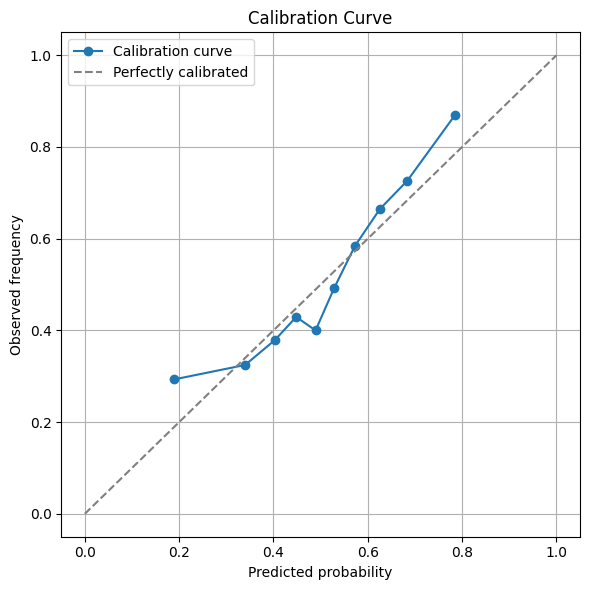

In [22]:
# calibration 
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

# y_true: true binary outcomes (0 or 1)
# y_prob: predicted probabilities from your classifier (e.g., model.predict_proba[:, 1])

# Compute calibration curve
prob_true, prob_pred = calibration_curve(y, train_o['pred_prob'], n_bins=10, strategy='quantile')

# Plot
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Predicted probability')
plt.ylabel('Observed frequency')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
#determining best threshlold
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import pandas as pd

# Ensure there are no NaNs and both arrays are numeric
y_true = y.astype(int)
y_score = train_o['pred_prob'].astype(float)

# Check for constant values (this causes roc_curve to fail)
if len(set(y_true)) < 2:
    raise ValueError("y_true has only one class. Need both positive and negative samples.")

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_true, y_score)

# Build Youden’s index table
youden = pd.DataFrame({
    'TPR': tpr,
    'FPR': fpr,
    'Cut-off': thresholds,
    'Youden': tpr - fpr
})

# Sort by Youden’s index
youden = youden.sort_values(by='Youden', ascending=False).reset_index(drop=True)

# Optional: show best cutoff
print("Best threshold:", youden.loc[0, 'Cut-off'])
youden.head()


Best threshold: 0.5345699770041971


,TPR,FPR,Cut-off,Youden
0,0.601626,0.267896,0.534570,0.333730
1,0.604675,0.271150,0.534078,0.333525
2,0.599593,0.266811,0.534931,0.332782
3,0.602642,0.270065,0.534197,0.332577
4,0.609756,0.277657,0.531462,0.332099


In [24]:
import pandas as pd

train_o['pred'] = train_o['pred_prob'].map(lambda x: 1 if x > 0.5345699770041971 else 0)

pd.crosstab(y, train_o['pred'])

pred,0,1
Label,,
0,675,247
1,393,591


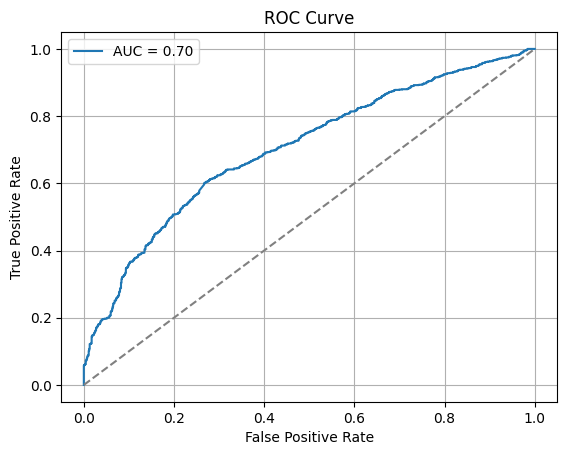

In [25]:
# Roc Curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

auc = roc_auc_score(y, train_o['pred_prob'])

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # chance line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

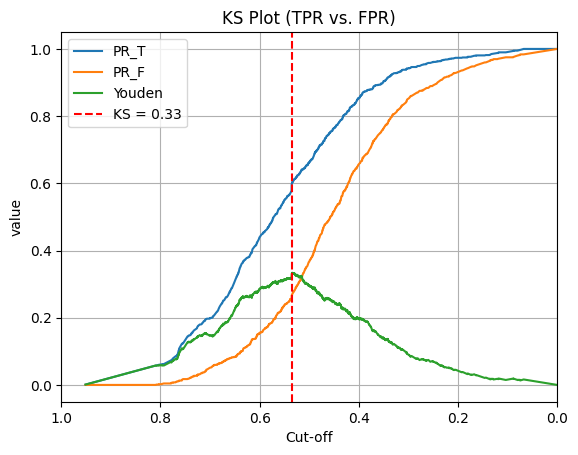

In [26]:
# KS plot 
import seaborn as sns

fpr, tpr, thresholds = roc_curve(y, train_o['pred_prob'])

# Create the Youden DataFrame
youden = pd.DataFrame({
    'Cut-off': thresholds,
    'TPR': tpr,
    'FPR': fpr,
    'Youden': tpr - fpr
})

# Sort by Cut-off and rename
youden = youden.sort_values(by='Cut-off', ascending=True)

ks_stat = youden.rename(columns={'TPR': 'PR_T', 'FPR': 'PR_F'})
ks_stat = ks_stat.melt(id_vars='Cut-off', var_name='PR', value_name='value')

ks_val = (youden['TPR'] - youden['FPR']).max()
ks_cutoff = youden.loc[(youden['TPR'] - youden['FPR']).idxmax(), 'Cut-off']

# Plot
sns.lineplot(x='Cut-off', y='value', hue='PR', data=ks_stat)
plt.xlim(1, 0)
plt.title("KS Plot (TPR vs. FPR)")
plt.grid(True)
plt.axvline(x=ks_cutoff, linestyle='--', color='red', label=f'KS = {ks_val:.2f}')
plt.legend()
plt.show()


In [27]:
# Precision, Recall, Cut-off, F1
train_o['Label'] = y
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

precision = np.array([])
recall = np.array([])
f1score = np.array([])

for y in range(100):
  train_o['pred'] = train_o['pred_prob'].map(lambda x: 1 if x > y/100 else 0)
  value_p = precision_score(train_o['Label'], train_o['pred'])
  precision = np.append(precision, value_p)
  value_r = recall_score(train_o['Label'], train_o['pred'])
  recall = np.append(recall, value_r)
  value_f = f1_score(train_o['Label'], train_o['pred'])
  f1score = np.append(f1score, value_f)

data = {'Precision': precision, 'Recall': recall, 'Cut-off': range(100), 'F1': f1score}
f1_s = pd.DataFrame(data)

f1_s.sort_values(by = ['F1'], ascending = False)

/home/appij25/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/appij25/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/appij25/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/appij25/.local/lib/python

,Precision,Recall,Cut-off,F1
39,0.578167,0.871951,39,0.695300
38,0.574086,0.878049,38,0.694255
37,0.566062,0.888211,37,0.691456
40,0.580913,0.853659,40,0.691358
33,0.550786,0.925813,33,0.690675
34,0.554121,0.915650,34,0.690421
32,0.548175,0.930894,32,0.690019
31,0.545508,0.938008,31,0.689836
35,0.557716,0.903455,35,0.689682
36,0.560587,0.893293,36,0.688871


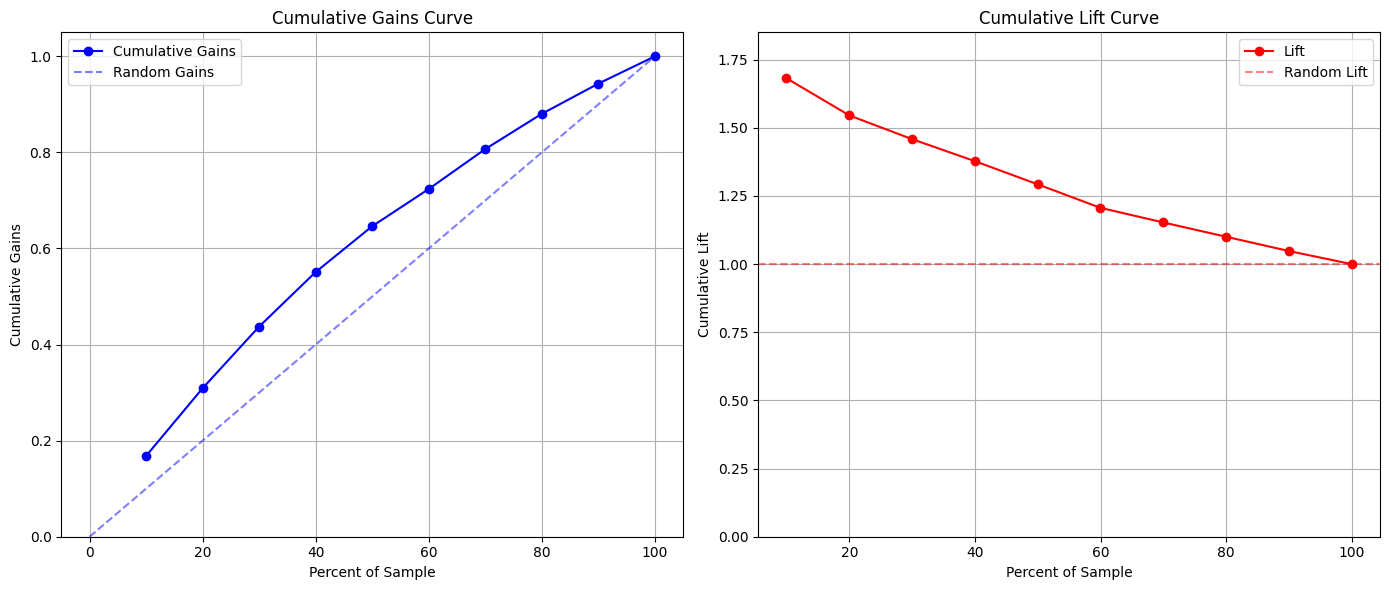

In [28]:
# Gains and lift Graph
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_lift_and_gains(y_true, y_proba, n_bins=10):
    """
    Plot Lift and Cumulative Gains curves.
    
    Parameters:
    - y_true: array-like, true binary labels (0/1)
    - y_proba: array-like, predicted probabilities for the positive class
    - n_bins: number of bins/deciles to split data
    
    Returns:
    - None (plots the curves)
    """
    df = pd.DataFrame({
        'y_true': y_true,
        'y_proba': y_proba
    })
    
    # Sort descending by predicted probability
    df = df.sort_values(by='y_proba', ascending=False).reset_index(drop=True)
    
    # Add cumulative counts
    df['cum_total'] = np.arange(1, len(df) + 1)
    df['cum_positives'] = df['y_true'].cumsum()
    
    total_positives = df['y_true'].sum()
    total_samples = len(df)
    
    # Cumulative Gains: % positives captured vs % samples
    df['cum_gains'] = df['cum_positives'] / total_positives
    
    # Lift: (cumulative gains) / (cumulative % of sample)
    df['cum_lift'] = df['cum_gains'] / (df['cum_total'] / total_samples)
    
    # Sample points for plotting (deciles)
    cutoffs = np.linspace(0, total_samples, n_bins + 1, dtype=int)
    cutoffs = cutoffs[cutoffs > 0]  # remove zero
    plot_points = df.loc[cutoffs - 1, ['cum_total', 'cum_gains', 'cum_lift']].copy()
    plot_points['percent_samples'] = plot_points['cum_total'] / total_samples * 100
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot Cumulative Gains
    axes[0].plot(plot_points['percent_samples'], plot_points['cum_gains'], marker='o', color='blue', label='Cumulative Gains')
    axes[0].plot([0, 100], [0, 1], linestyle='--', color='blue', alpha=0.5, label='Random Gains')
    axes[0].set_xlabel('Percent of Sample')
    axes[0].set_ylabel('Cumulative Gains')
    axes[0].set_title('Cumulative Gains Curve')
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(True)
    axes[0].legend()
    
    # Plot Lift
    axes[1].plot(plot_points['percent_samples'], plot_points['cum_lift'], marker='o', color='red', label='Lift')
    axes[1].axhline(1, linestyle='--', color='red', alpha=0.5, label='Random Lift')
    axes[1].set_xlabel('Percent of Sample')
    axes[1].set_ylabel('Cumulative Lift')
    axes[1].set_title('Cumulative Lift Curve')
    axes[1].set_ylim(0, plot_points['cum_lift'].max() * 1.1)
    axes[1].grid(True)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# Example:
plot_lift_and_gains(train_o['Label'], train_o['pred_prob'])


## Transforming the test 

In [29]:
test_o= test.copy()
num_cols_test = test_o.select_dtypes(include='number').columns

for col in num_cols_test:
    if test_o[col].isnull().any():
        # Create missing flag column
        test_o[f'{col}_was_missing'] = test_o[col].isnull().astype(int)

        # Impute with median
        median = test_o[col].median()
        test_o[col] = test_o[col].fillna(median)
print(test_o.columns)

Index(['Label', 'EDA_mean_delta', 'EDA_median_delta', 'EDA_sd_delta',
       'SCR_count_delta', 'SCR_amp_delta', 'HR_median_delta',
       'TEMP_median_delta', 'ACC_vm_mean_delta', 'ACC_vm_sd_delta',
       'HR_bangle_delta', 'HR_conf_delta', 'RMSSD_ECG_delta'],
      dtype='object')


In [33]:
# Prepare test predictors
predictors_test = test_o.drop(columns=['Label'])
predictors_test = pd.get_dummies(predictors_test, drop_first=True)
predictors_test = predictors_test.astype(float)

# Align columns with training set
train_columns = X_reduced.columns  

# Add missing columns
for col in train_columns:
    if col not in predictors_test.columns:
        predictors_test[col] = 0

# Keep only training columns and order them
predictors_test = predictors_test[train_columns]

# Final X_test
X_test = predictors_test


y_test = test_o['Label'].map({'NOSTRESS': 0, 'STRESS': 1})


In [34]:
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error, log_loss, brier_score_loss,
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)

# --- Align test features with training features ---
# X_selected: columns used in training
# X_reduced_test: selected features in test set
# selected_features contains the features used to train the model (including 'const')
common_features = [f for f in selected_features if f != 'const']

# Make sure all columns exist in X_test
X_test1 = X_test[common_features].copy()

# Add constant only if the model had it
X_test1 = sm.add_constant(X_test1, has_constant='add')

# Align columns exactly as in training
missing_cols = set(result_w.params.index) - set(X_test1.columns)
for col in missing_cols:
    X_test1[col] = 0  # fill missing columns with 0

# Reorder columns to match model
X_test1 = X_test1[result_w.params.index]

# Predict
y_pred_prob = result_w.predict(X_test1)


In [35]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, recall_score,
    precision_score, f1_score, confusion_matrix, classification_report
)

# --- Convert probabilities to binary predictions using best threshold ---
best_threshold = 0.5345699770041971  # optimal threshold
y_pred_binary = (y_pred_prob >= best_threshold).astype(int)

# --- Classification metrics ---
accuracy = accuracy_score(y_test, y_pred_binary)
auc = roc_auc_score(y_test, y_pred_prob)   # uses probabilities, not binary
recall = recall_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
f1 = f1_score(y_test, y_pred_binary)

# --- Display results ---
print("====== CLASSIFICATION PERFORMANCE (BINARY TARGET) ======")
print(f"Best Threshold: {best_threshold:.6f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

print("\n====== CONFUSION MATRIX ======")
print(confusion_matrix(y_test, y_pred_binary))

print("\n====== CLASSIFICATION REPORT ======")
print(classification_report(y_test, y_pred_binary, digits=4))


====== CLASSIFICATION PERFORMANCE (BINARY TARGET) ======
Best Threshold: 0.534570
Accuracy: 0.6094
ROC-AUC: 0.6538
Precision: 0.6399
Recall: 0.5579
F1 Score: 0.5961

====== CONFUSION MATRIX ======
[[204 103]
 [145 183]]

====== CLASSIFICATION REPORT ======
              precision    recall  f1-score   support

           0     0.5845    0.6645    0.6220       307
           1     0.6399    0.5579    0.5961       328

    accuracy                         0.6094       635
   macro avg     0.6122    0.6112    0.6090       635
weighted avg     0.6131    0.6094    0.6086       635

